## Foodpanda Data Analysis - Data Science Project
## Question 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Imports & Data Reading

In [2]:
file = "Foodpanda Analysis Dataset.csv" 
df = pd.read_csv(file)

print(df.shape)
df.head()

(6000, 20)


,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,8/23/2023,McDonald's,Burger,Italian,5,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,3,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,2,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,4,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,8/24/2023,KFC,Sandwich,Dessert,1,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      6000 non-null   str    
 1   gender           6000 non-null   str    
 2   age              6000 non-null   str    
 3   city             6000 non-null   str    
 4   signup_date      6000 non-null   str    
 5   order_id         6000 non-null   str    
 6   order_date       6000 non-null   str    
 7   restaurant_name  6000 non-null   str    
 8   dish_name        6000 non-null   str    
 9   category         6000 non-null   str    
 10  quantity         6000 non-null   int64  
 11  price            6000 non-null   float64
 12  payment_method   6000 non-null   str    
 13  order_frequency  6000 non-null   int64  
 14  last_order_date  6000 non-null   str    
 15  loyalty_points   6000 non-null   int64  
 16  churned          6000 non-null   str    
 17  rating           6000 non

In [4]:
df.shape

(6000, 20)

### Data Preprocessing

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.drop_duplicates()

date_columns = ['signup_date', 'order_date', 'last_order_date', 'rating_date']
for column in date_columns:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors='coerce')

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()
    
missing_count_by_col = df.isnull().sum().sort_values(ascending=False)
print(missing_count_by_col)

df = df.dropna(subset=['churned', 'order_frequency'])

if 'city' in df.columns:
    df['city'] = df['city'].fillna('Unknown')
if 'loyalty_points' in df.columns:
    df['loyalty_points'] = df['loyalty_points'].fillna(df['loyalty_points'].median())

df = df.dropna(subset=['signup_date', 'last_order_date', 'order_date'])
df = df[(df['last_order_date'] >= df['signup_date'])].copy()

# Reference Date for Analysis (21st October 2025 - 2 months after last order)
reference_date = pd.Timestamp('2025-10-21')

# Order recency calculation
df['recency_days'] = (reference_date - df['last_order_date']).dt.days

df['order_quarter'] = df['order_date'].dt.to_period('Q')

# Data Grouping
df['loyalty_group'] = pd.cut(
    df['loyalty_points'],
    bins=[-1, 167, 333, 500],
    labels=['Low', 'Medium', 'High']
)

df['frequency_group'] = pd.cut(
    df['order_frequency'],
    bins=[0, 17, 34, 50],
    labels=['Low', 'Medium', 'High']
)

df['recency_group'] = pd.cut(
    df['recency_days'],
    bins=[0, 30, 90, 365, 9999],
    labels=['Recent', 'Moderate', 'Old', 'Very Old']
)

df['order_year'] = df['order_date'].dt.year
df['churn_flag'] = df['churned'].apply(lambda x: 1 if x == 'Inactive' else 0)
df['tenure_days'] = (df['last_order_date'] - df['signup_date']).dt.days

customer_id        0
gender             0
age                0
city               0
signup_date        0
order_id           0
order_date         0
restaurant_name    0
dish_name          0
category           0
quantity           0
price              0
payment_method     0
order_frequency    0
last_order_date    0
loyalty_points     0
churned            0
rating             0
rating_date        0
delivery_status    0
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_12076\4205341796.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [6]:
df.shape

(4533, 28)

### Overall Analysis by Age, Loyalty, Order Frequency

Overall churn baseline: 49.9%


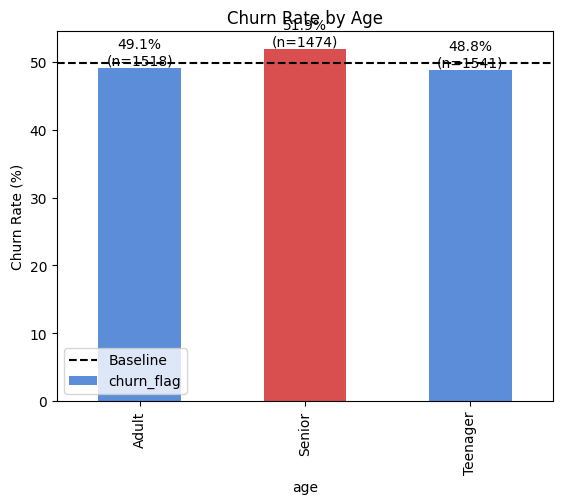

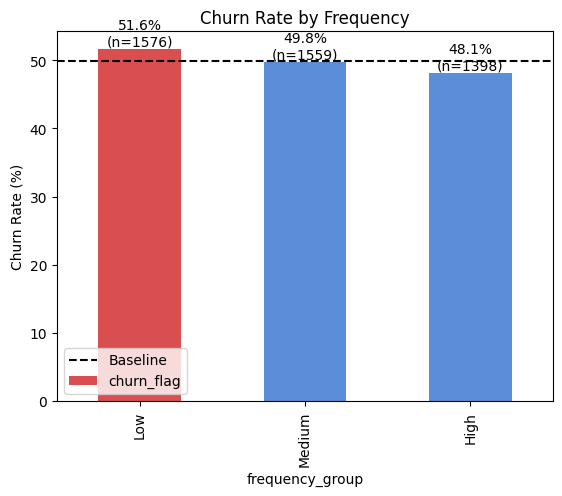

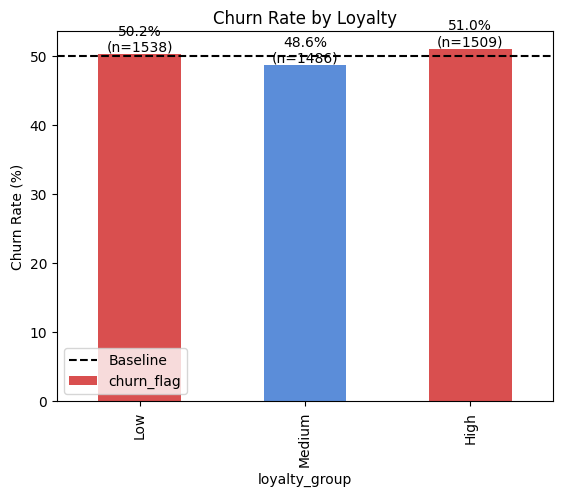

In [7]:
BASELINE = df['churn_flag'].mean() * 100
print(f"Overall churn baseline: {BASELINE:.1f}%")

# Age
age_churn = df.groupby('age')['churn_flag'].mean() * 100
age_size = df.groupby('age').size()

colors = []
for rate in age_churn:
    if rate > BASELINE:
        colors.append('#d94f4f')  
    else:
        colors.append('#5b8dd9')  

ax = age_churn.plot(kind='bar', color=colors)
for bar, (age, rate) in zip(ax.patches, age_churn.items()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(round(rate,1)) + "%\n(n=" + str(age_size[age]) + ")",
        ha='center'
    )

plt.axhline(BASELINE, linestyle='--', color='black',
            label="Baseline")
plt.title("Churn Rate by Age")
plt.ylabel("Churn Rate (%)")
plt.legend()
plt.show()

# Frequency
freq_churn = df.groupby('frequency_group')['churn_flag'].mean() * 100
freq_size = df.groupby('frequency_group').size()

colors = []
for rate in freq_churn:
    if rate > BASELINE:
        colors.append('#d94f4f')
    else:
        colors.append('#5b8dd9')

ax = freq_churn.plot(kind='bar', color=colors)
for bar, (group, rate) in zip(ax.patches, freq_churn.items()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(round(rate,1)) + "%\n(n=" + str(freq_size[group]) + ")",
        ha='center'
    )

plt.axhline(BASELINE, linestyle='--', color='black',
            label="Baseline")
plt.title("Churn Rate by Frequency")
plt.ylabel("Churn Rate (%)")
plt.legend()
plt.show()

# Loyalty
loyalty_churn = df.groupby('loyalty_group')['churn_flag'].mean() * 100
loyalty_size = df.groupby('loyalty_group').size()

colors = []
for rate in loyalty_churn:
    if rate > BASELINE:
        colors.append('#d94f4f')
    else:
        colors.append('#5b8dd9')

ax = loyalty_churn.plot(kind='bar', color=colors)
for bar, (group, rate) in zip(ax.patches, loyalty_churn.items()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(round(rate,1)) + "%\n(n=" + str(loyalty_size[group]) + ")",
        ha='center'
    )

plt.axhline(BASELINE, linestyle='--', color='black',
            label="Baseline")
plt.title("Churn Rate by Loyalty")
plt.ylabel("Churn Rate (%)")
plt.legend()
plt.show()

### Quarterly Analysis

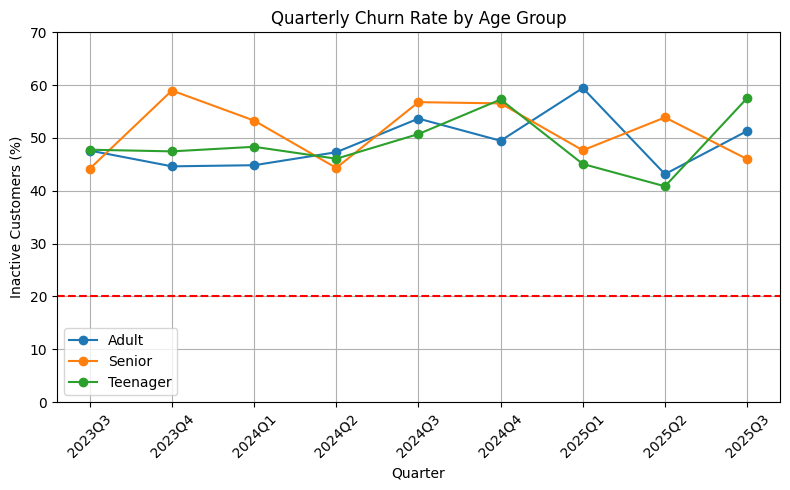

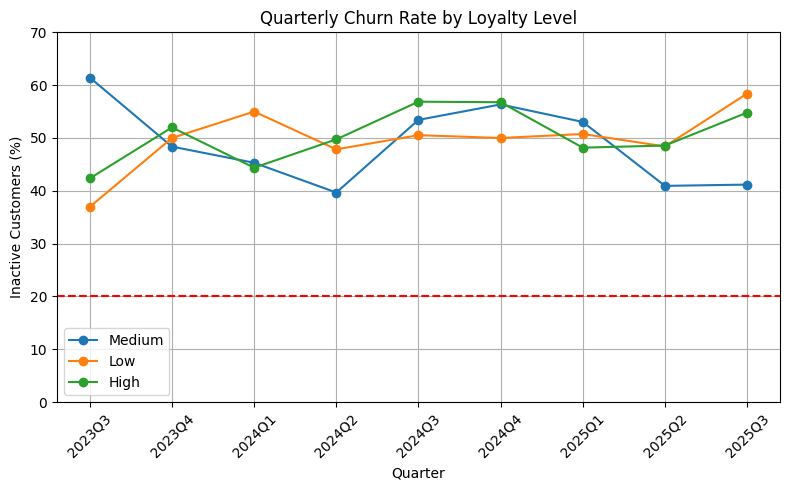

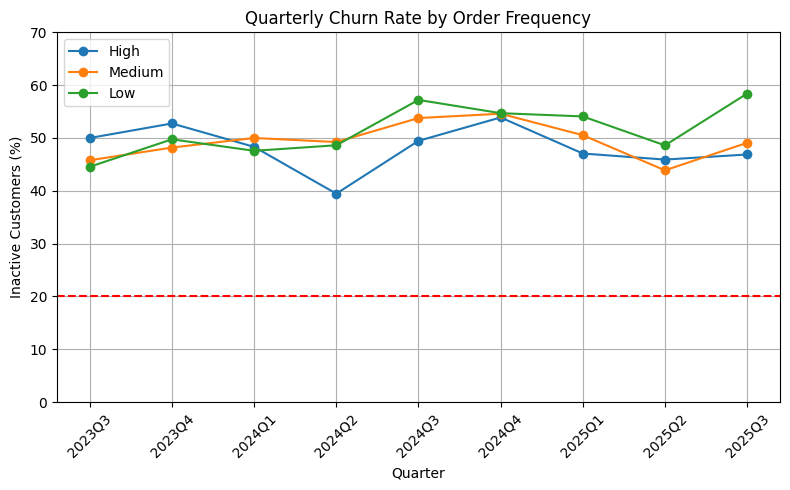

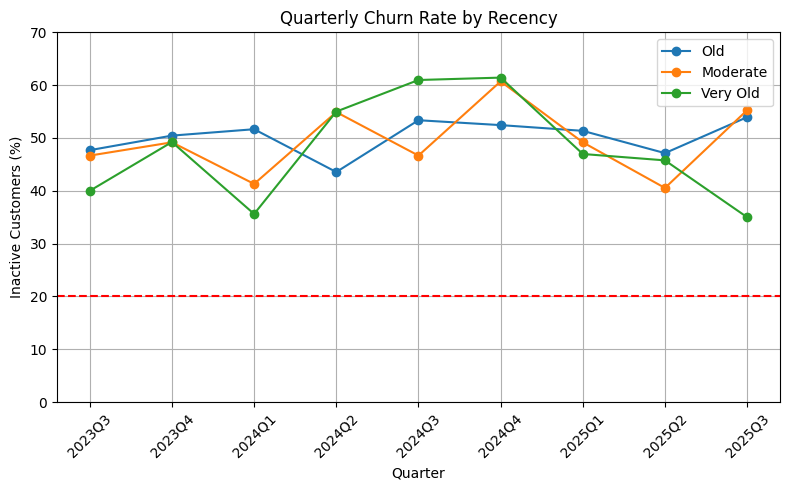

In [8]:
def quarterly_churn_plot(column_name, title):

    plt.figure(figsize=(8,5))
    plt.ylim(0,70)

    groups = df[column_name].dropna().unique()

    for group in groups:

        temp = df[df[column_name] == group]

        quarterly = pd.crosstab(
            temp['order_quarter'],
            temp['churned'],
            normalize='index'
        ) * 100

        if 'Inactive' in quarterly.columns:
            plt.plot(
                quarterly.index.astype(str),
                quarterly['Inactive'],
                marker='o',
                label=str(group)
            )

    plt.axhline(20, color='red', linestyle='--', linewidth=1.5)
    plt.title(title)
    plt.xlabel('Quarter')
    plt.ylabel('Inactive Customers (%)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('Quarterly Churn Trend.png')
    plt.show()

quarterly_churn_plot('age','Quarterly Churn Rate by Age Group')
quarterly_churn_plot('loyalty_group','Quarterly Churn Rate by Loyalty Level')
quarterly_churn_plot('frequency_group','Quarterly Churn Rate by Order Frequency')
quarterly_churn_plot('recency_group','Quarterly Churn Rate by Recency')

### Yearly Analysis

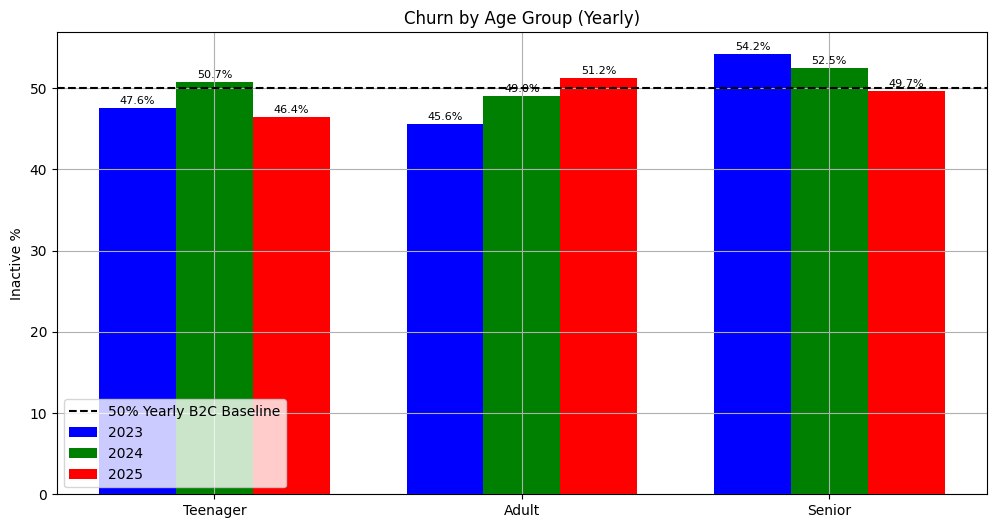

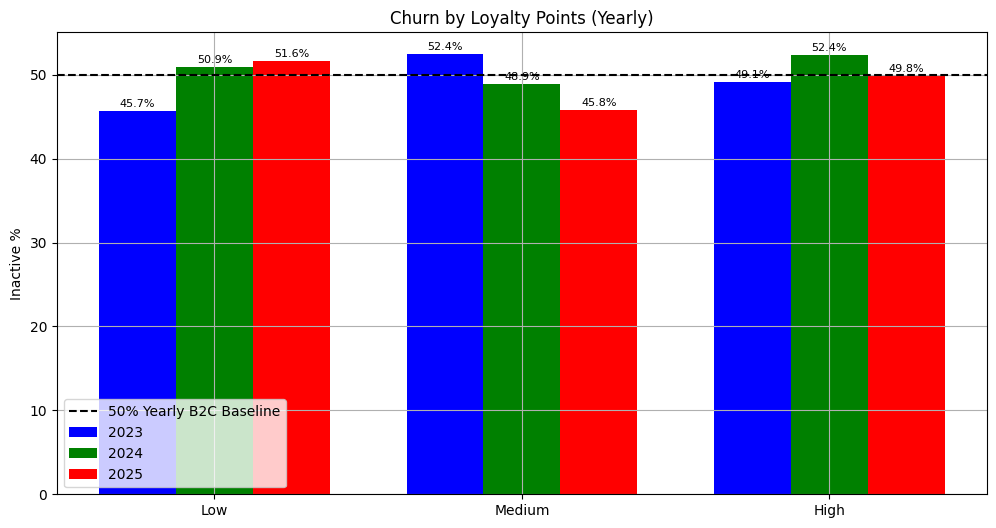

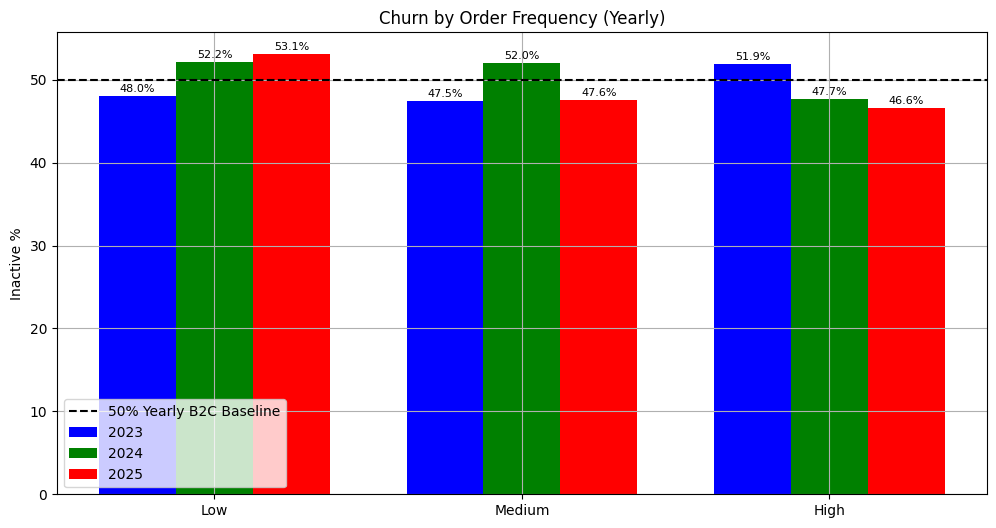

In [9]:
years = [2023, 2024, 2025]
colors = {2023: 'blue', 2024: 'green', 2025: 'red'}
width = 0.25

def plot_group(column, groups, title):
    x = np.arange(len(groups))
    fig, ax = plt.subplots(figsize=(12,6))
    
    for i, year in enumerate(years):
        temp = df[df['order_year'] == year]
        table = pd.crosstab(temp[column], temp['churned'], normalize='index') * 100
        
        values = [
            table.loc[g, 'Inactive'] if g in table.index else 0
            for g in groups
        ]

        bars = ax.bar(x + (i - 1) * width, values,
                      width=width, color=colors[year], label=str(year))

        for b, v in zip(bars, values):
            ax.text(b.get_x() + b.get_width()/2,
                    b.get_height() + 0.5,
                    f'{v:.1f}%', ha='center', fontsize=8)
    plt.axhline(50, color = 'black', linestyle='--', linewidth = 1.5, label = '50% Yearly B2C Baseline')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylabel('Inactive %')
    ax.legend()
    ax.grid(True)
    plt.savefig('Yearly Churn.png')
    plt.show()

plot_group('age',['Teenager','Adult','Senior'],'Churn by Age Group (Yearly)')
plot_group('loyalty_group',['Low','Medium','High'],'Churn by Loyalty Points (Yearly)')
plot_group('frequency_group',['Low','Medium','High'],'Churn by Order Frequency (Yearly)')

### Trend Analysis

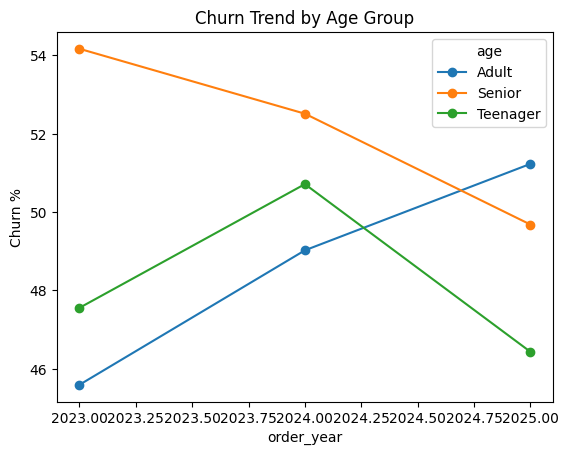

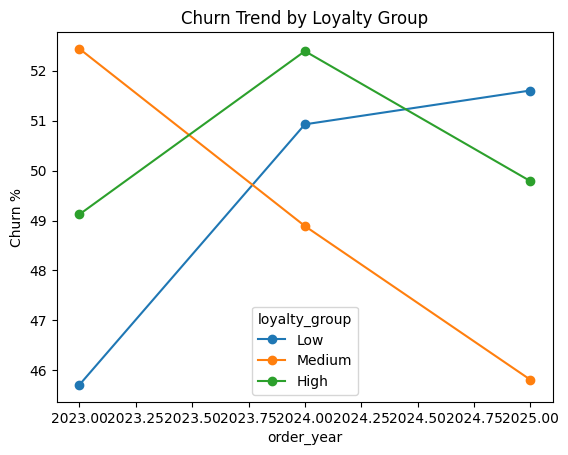

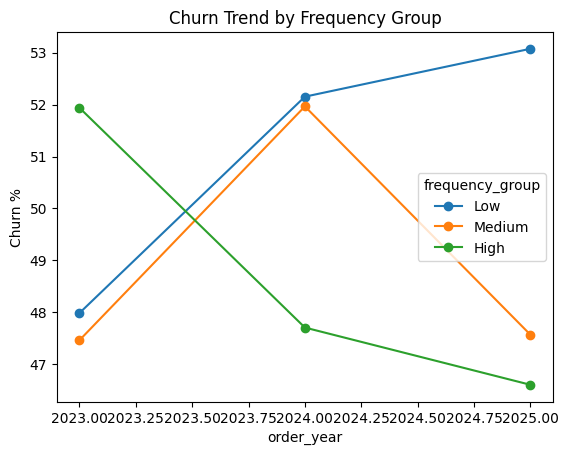

In [12]:
# Age Group Trend
age_trend = df.groupby(['order_year','age'])['churn_flag'].mean().unstack() * 100
age_trend.plot(marker='o')
plt.title('Churn Trend by Age Group')
plt.ylabel('Churn %')
plt.savefig('Churn Trend by Age Group.png')
plt.show()

# Loyalty Group Trend
loyalty_trend = df.groupby(['order_year','loyalty_group'])['churn_flag'].mean().unstack() * 100
loyalty_trend.plot(marker='o')
plt.title('Churn Trend by Loyalty Group')
plt.ylabel('Churn %')
plt.savefig('Churn Trend by Loyalty Group.png')
plt.show()

# Order Frequency Group Trend
freq_trend = df.groupby(['order_year','frequency_group'])['churn_flag'].mean().unstack() * 100
freq_trend.plot(marker='o')
plt.title('Churn Trend by Frequency Group')
plt.ylabel('Churn %')
plt.savefig('Churn Trend by Frequency Group.png')
plt.show()

### Analysis by Customer Rating and Customer Overall Tenure

churned
Active      2.956828
Inactive    3.028723
Name: rating, dtype: float64


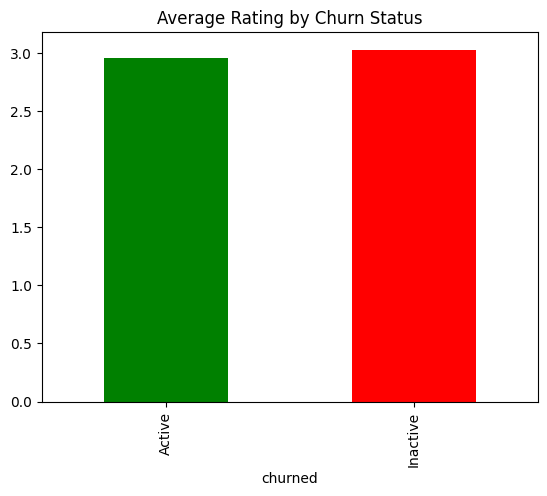

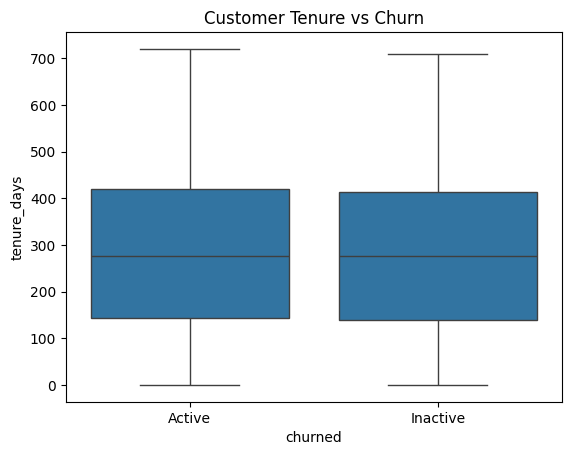

In [13]:
# Customer Rating
rating_churn = df.groupby('churned')['rating'].mean()
print(rating_churn)

rating_churn.plot(kind='bar', color=['green','red'])
plt.title('Average Rating by Churn Status')
plt.show()

# Customer Tenure
sns.boxplot(x='churned', y='tenure_days', data=df)
plt.title('Customer Tenure vs Churn')
plt.show()

### Analysis by Grouping Variables (Age x Frequency x Loyalty)

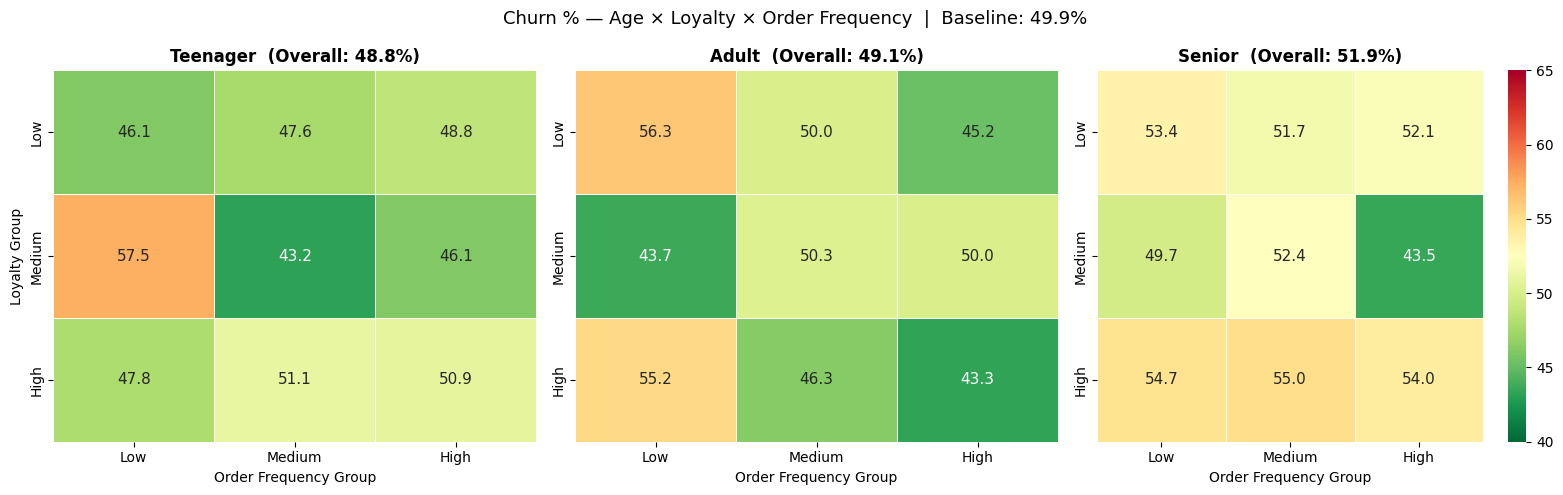

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, age in zip(axes, ['Teenager', 'Adult', 'Senior']):
    subset = df[df['age'] == age]
    heat   = (
        subset.groupby(['loyalty_group', 'frequency_group'])['churn_flag']
        .mean().unstack() * 100
    )
    heat = heat.reindex(index=['Low', 'Medium', 'High'],
                        columns=['Low', 'Medium', 'High'])

    overall_rate = df[df['age'] == age]['churn_flag'].mean() * 100

    sns.heatmap(
        heat, ax=ax,
        annot=True, fmt=".1f",
        cmap="RdYlGn_r",
        vmin=40, vmax=65,
        cbar=(age == 'Senior'),
        linewidths=0.5,
        annot_kws={"size": 11}
    )
    ax.set_title(f'{age}  (Overall: {overall_rate:.1f}%)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Order Frequency Group')
    ax.set_ylabel('Loyalty Group' if age == 'Teenager' else '')

fig.suptitle(
    f'Churn % — Age × Loyalty × Order Frequency  |  Baseline: {BASELINE:.1f}%',
    fontsize=13
)
plt.tight_layout()
plt.savefig('3-Way Churn Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Summary
age_rates  = df.groupby('age')['churn_flag'].mean() * 100
loy_rates  = df.groupby('loyalty_group')['churn_flag'].mean() * 100
freq_rates = df.groupby('frequency_group')['churn_flag'].mean() * 100

print("=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"\nBaseline churn rate: {BASELINE:.1f}%\n")
print("Age group churn rates:")
for age, rate in age_rates.sort_values(ascending=False).items():
    flag = " ← highest risk" if rate == age_rates.max() else ""
    print(f"  {age:10s}: {rate:.1f}%{flag}")

print("\nLoyalty group churn rates:")
for grp, rate in loy_rates.sort_values(ascending=False).items():
    flag = " ← highest risk" if rate == loy_rates.max() else ""
    print(f"  {grp:10s}: {rate:.1f}%{flag}")

print("\nFrequency group churn rates:")
for grp, rate in freq_rates.sort_values(ascending=False).items():
    flag = " ← highest risk" if rate == freq_rates.max() else ""
    print(f"  {grp:10s}: {rate:.1f}%{flag}")

SUMMARY

Baseline churn rate: 49.9%

Age group churn rates:
  Senior    : 51.9% ← highest risk
  Adult     : 49.1%
  Teenager  : 48.8%

Loyalty group churn rates:
  High      : 51.0% ← highest risk
  Low       : 50.2%
  Medium    : 48.6%

Frequency group churn rates:
  Low       : 51.6% ← highest risk
  Medium    : 49.8%
  High      : 48.1%


In [14]:
df_export = df.copy()
for col in ['signup_date', 'order_date', 'last_order_date', 'rating_date']:
    if col in df_export.columns:
        df_export[col] = df_export[col].dt.strftime('%Y-%m-%d')

df_export.to_csv('Foodpanda_Clean.csv', index=False)
print(f"Saved: {df_export.shape[0]} rows, {df_export.shape[1]} columns")
print("Columns included:", df_export.columns.tolist())

Saved: 4533 rows, 28 columns
Columns included: ['customer_id', 'gender', 'age', 'city', 'signup_date', 'order_id', 'order_date', 'restaurant_name', 'dish_name', 'category', 'quantity', 'price', 'payment_method', 'order_frequency', 'last_order_date', 'loyalty_points', 'churned', 'rating', 'rating_date', 'delivery_status', 'recency_days', 'order_quarter', 'loyalty_group', 'frequency_group', 'recency_group', 'order_year', 'churn_flag', 'tenure_days']
